# 3.1 Кластерный анализ методом k - средних

## 2 вида задач

**1.Кластерный анализ** - анализирует наблюдения (по строкам). Определяет есть ли в данных группировка наблюдений по разным кластерам, а также сколько таких кластеров можно выделить.

**2.Анализ главных компонент(PCA)** - анализирует наблюдения (по столбцам). Используется для снижения размерности набора данных. Преобразовывет взаимосвязанные переменные в независимую переменную(главная компонента). 

## Алгоритм кластерного анализа методом k-средних (где k-кол-во кластеров)

1. Решается на какое количество кластеров будут поделены наблюдения;
2. Случайно выбираются начальные позиции центроидов кластера. Центроиды - геометрические центры предполагаемых кластеров с координатами:
[срeднее значение всех наблюдений кластера по оси X ; срeднее значение всех наблюдений кластера по оси Y];
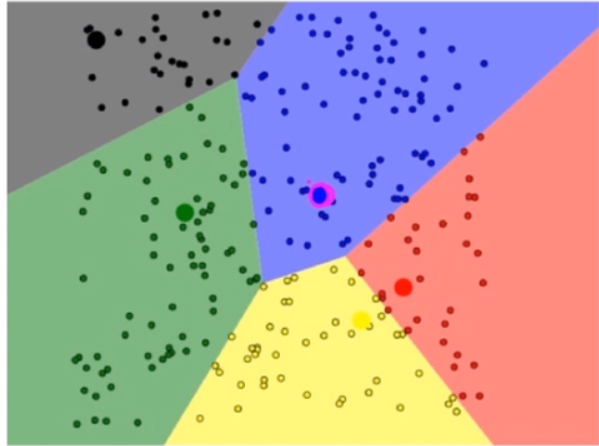
Для каждого наблюдения определяется, к какому центроиду оно ближе всего;
3. Обновляются позиции центроидов (среднее по каждой переменной для группы);
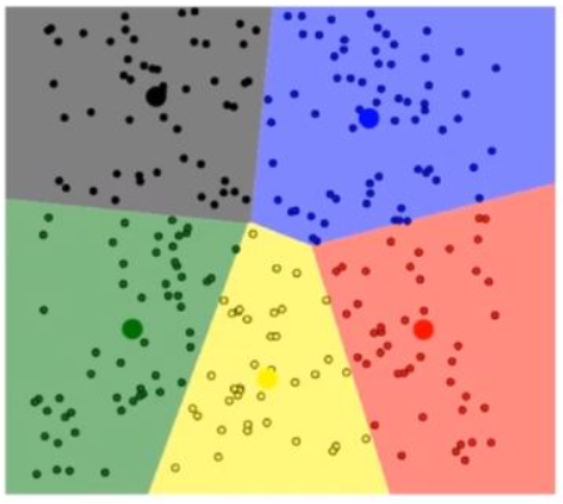 
5. Снова определяются принадлежности наблюдений, обновляются позиции центроидов и т.д. пока алгоритм не сойдется.

Cайт с визуализацией кластерного анализа: https://www.naftaliharris.com/blog/visualizing-k-means-clustering/

## Пример кластерного анализа на датасете iris 

In [55]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings('ignore')

In [45]:
""" Пример кластерного анализа на датасете iris """

# Загружаем датасет
iris = load_iris()

# Создаем DataFrame для удобства работы
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


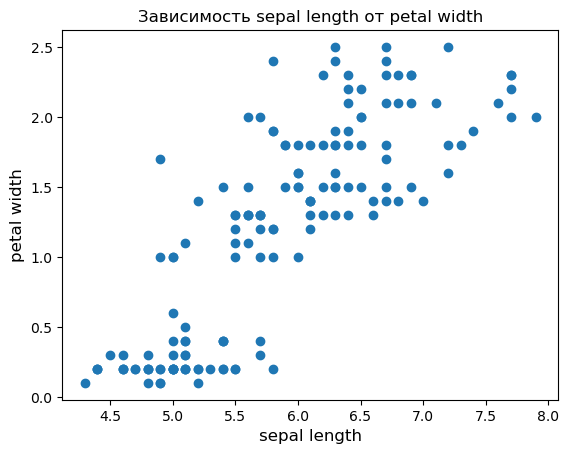

In [52]:
# визуализация данных
plt.scatter(iris_df["sepal length (cm)"], iris_df["petal width (cm)"])

plt.title('Зависимость sepal length от petal width', fontsize=12)
plt.xlabel('sepal length', fontsize=12)
plt.ylabel('petal width', fontsize=12)

plt.show()

In [151]:
# определяется количество кластеров 
clusters =('red', 'green', 'blue') # цвета для легенды графика
n_clusters = len(clusters)

# деление на кластеры
X = iris_df[["sepal length (cm)", "petal width (cm)"]].values
k_means_model = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, random_state=42)
y = k_means_model.fit_predict(X)

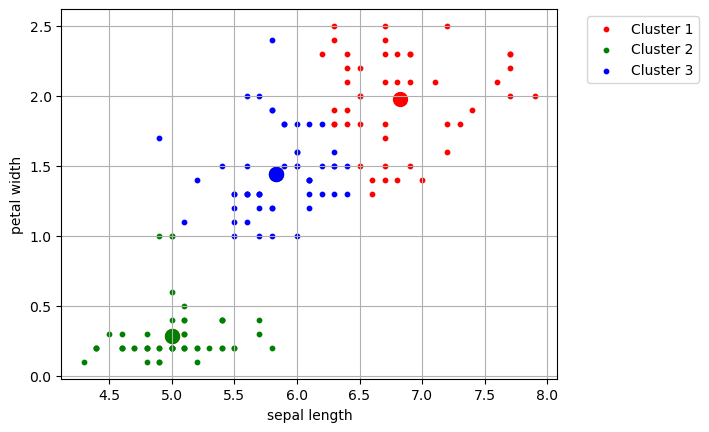

In [161]:
# визуализация групп и их центроидов
for i, color in enumerate(clusters):
    plt.scatter(X[y==i, 0], X[y==i, 1], s=10, c=color, label = f'Cluster {i+1}')
    plt.scatter(k_means_model.cluster_centers_[i:, 0], k_means_model.cluster_centers_[i:, 1], s=100, c=color)

# заголовки
plt.xlabel("sepal length")
plt.ylabel("petal width")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid()
plt.show()

# 3.2 Может ли кластерный анализ "ошибаться"?

## Основные определения и тезисы:   
Поскольку в методе существует элемент случайности, при многократном повторении кластеризации на одних и тех же данных можно получить различные варианты кластерного решения. Чем менее явно представлена в данных кластерзация наблюдений, тем более существенными могут оказаться различия.  

Могут получиться и подобные решения:  
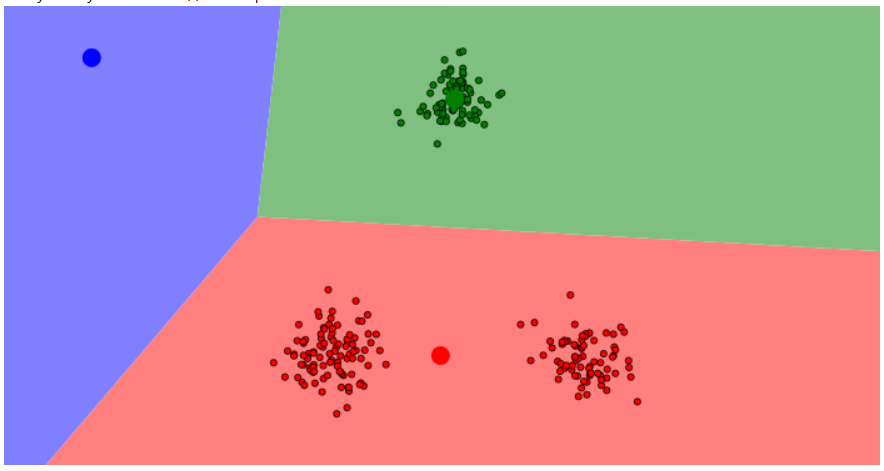
**Решения, если метод сошелся "неудачно (алгоритм увяз в локальном минимуме)"**:  
1) Брать начальные точки наиболее далеко друг от друга;  
2) Провести кластерный анализ несколько раз с разными начальными позициями (Если каждый раз из разных случайных начальных положений центроидов, кластерный анализ приходит в одно и то же положение, скорее всего, это не случайно);  
3) Изменить количество центроидов.

# 3.3 Как определить оптимальное число кластеров?

## Основные определения и тезисы:   
**Внутригрупповая сумма квадратов(within-cluster sum of squares)** - сумма квадратов отклонений каждого наблюдения от центроида кластера.  

**Общая внутригрупповая сумма квадратов(total within-cluster sum of squares)** - сумма внутригрупповых сумм квадратов.  


Для того, чтобы выяснить, какое число кластеров оптимально, можно многократно проводить кластерный анализ. Каждый раз выделяя разное количество кластеров и записывая значение общей внутрикластерной суммы квадратов:  
* Если добавление одного кластера в данные **значительно понижает общую сумму квадратов**, то в увеличении числа кластеров есть смысл;  
* Если последующее увеличение кластеров уже **не оказывает сильного влияния**, значит оптимальное число кластеров найдено;  
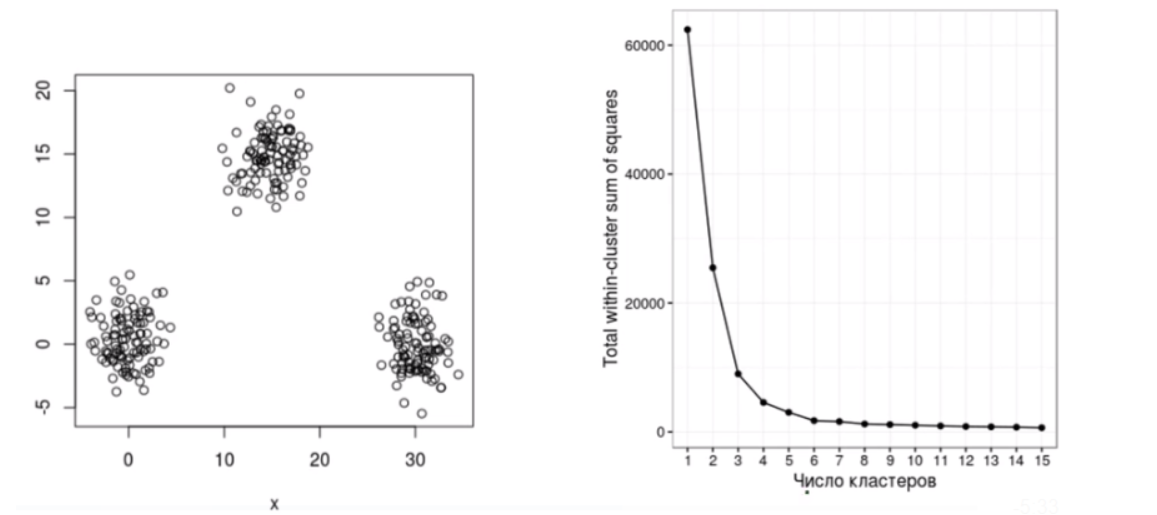 
* Если при увеличении числа кластеров идет **плавное снижение общей внтуригрупповой суммы квадратов**, значит в данных нет явной кластерной структуры.  
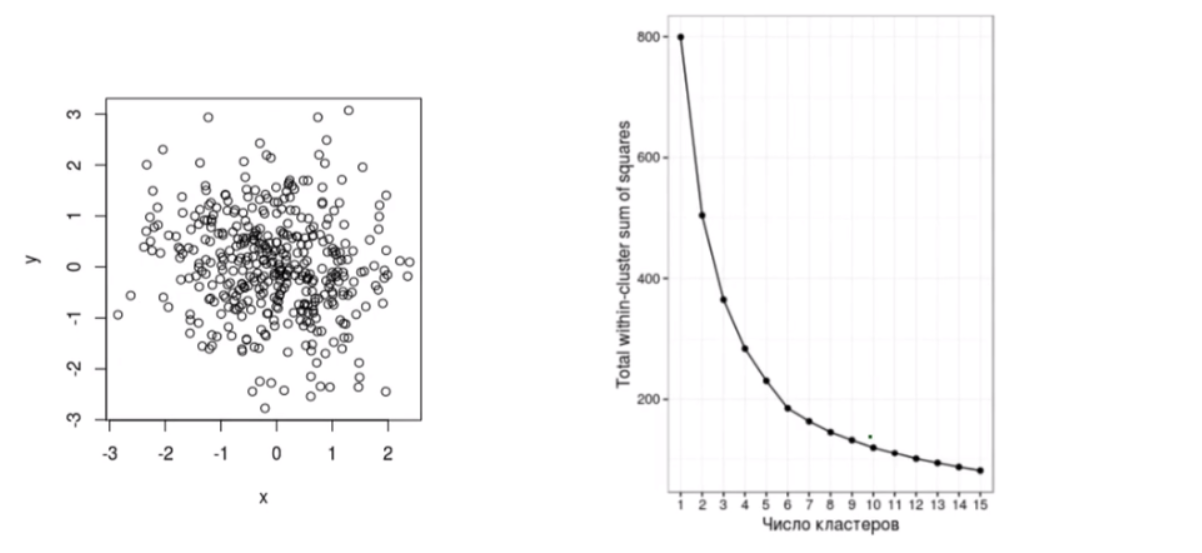

## Задача

Предположим, это один из кластеров в наших данных, тогда чему будет равняться внутрикластерная сумма квадратов?

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

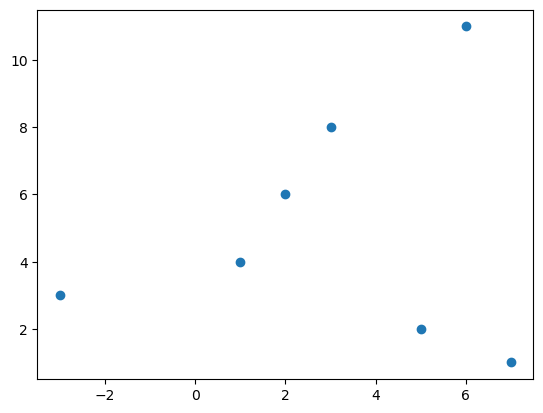

In [20]:
x = [-3, 1, 2, 3, 5, 6, 7]
y = [3, 4, 6, 8, 2, 11, 1]
plt.scatter(x , y)

In [27]:
# расчет ручками
c = [np.mean(x),  np.mean(y)] # центроид
wcss = [0 , 0]

for i in range(len(x)):
    wcss[0] += (x[i] - c[0])**2
    wcss[1] += (y[i] - c[1])**2
    
print("centroid =", c)
print("WCSS =",sum(wcss))

centroid = [3.0, 5.0]
WCSS = 146.0


In [30]:
""" Рассчет через sklearn """
# координаты точек в виде массива numpy
X = np.array([[-3, 3], [1, 4], [2, 6], [3, 8], [5, 2], [6, 11], [7, 1]])
# Обучение модель KMeans на массиве с одним кластером
kmeans = KMeans(n_clusters=1).fit(X)
# Вывод координат центроида данного кластера
print(kmeans.cluster_centers_)
# Вывод суммы квадратов расстояний точек от центроида = аттрибут модели kmeans
print(kmeans.inertia_)

[[3. 5.]]
146.0


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# 3.4 Иерархическая кластеризация

### Основные определения и тезисы:   
**Алгоритм**:  
1) Рассчитывается расстояние между всеми наблюдениями (от каждого наблюдения высчитывается расстояние до всех остальных). Число кластеров = числу наблюдений;  
2) Производится кластеризация методами иереархической кластеризации, например:  
* **Метод одиночной связи (ближайшего соседа/kNearestNeighbor/kNN)** - в первую очередь объединяет самые близкие точки в кластер, заменяя их центроидом. Затем рассчитывает расстояния между получившимся центроидом и остальными наблюдениями и опять объединяет ближайшие точки;  
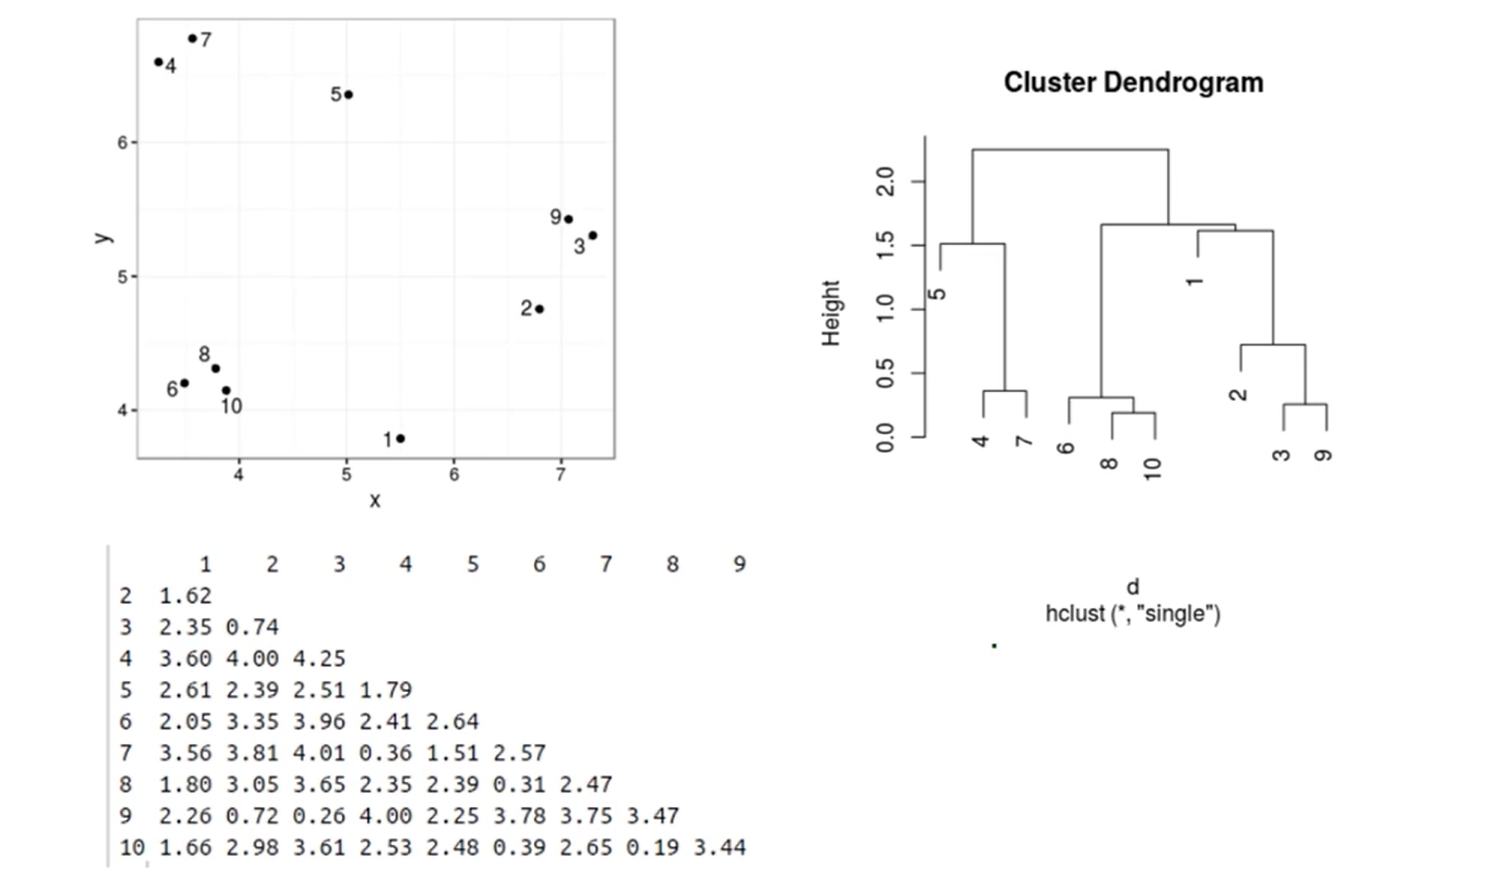
* **Метод дальнего соседа** - в последнюю очередь объединяет самые близкие точки.
3) Кластеризация происходит до тех пор, пока все наблюдения не останутся в одном кластере.  

Методы иерархической кластеризации и k-средних можно комбинировать. Сначала применить метод иерархической кластеризации, оценить полученное количество веток, и использовать это число для метода k-средних.

## Код на python

In [48]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

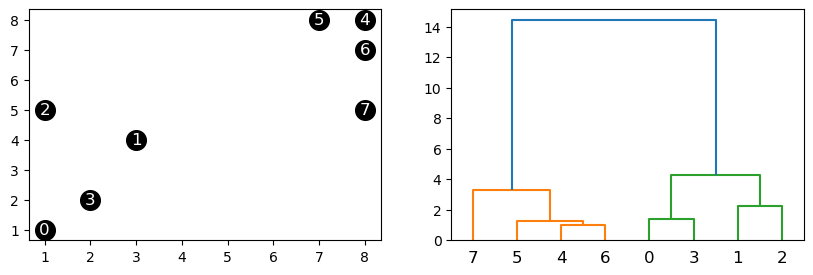

In [73]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
plt.subplots_adjust(hspace=0.5)

points = np.array([[1,1], [3,4], [1,5], [2,2], [8,8], [7,8], [8,7], [8,5]], dtype=float)
x, y = np.split(points, 2, axis=1)
labels = np.arange(0,8) # номер точек

# точки на графике
plt.subplot(1, 2, 1)
plt.scatter(x , y, s=200, c = "black")
for i, label in enumerate(labels):
    plt.text(x[i], y[i], label, c="white", fontsize=12, ha='center', va='center')

# дендограмма кластеров
plt.subplot(1, 2, 2)
Z = linkage(points, 'ward') # Вычисление расстояний
dn = dendrogram(Z) # Построение дендрограммы

plt.show()

Особое внимание стоит уделить тому, как происходит выбор числа кластеров при иерархической кластеризации. Как я сказал, в этом случае у нас есть некоторая свобода в том, какое число кластеров выбрать, но то как исходные данные разделятся на выбранное число кластеров все-таки подчиняется логике работы алгоритма. Рассмотрим пример кластеризации следующего набора данных:
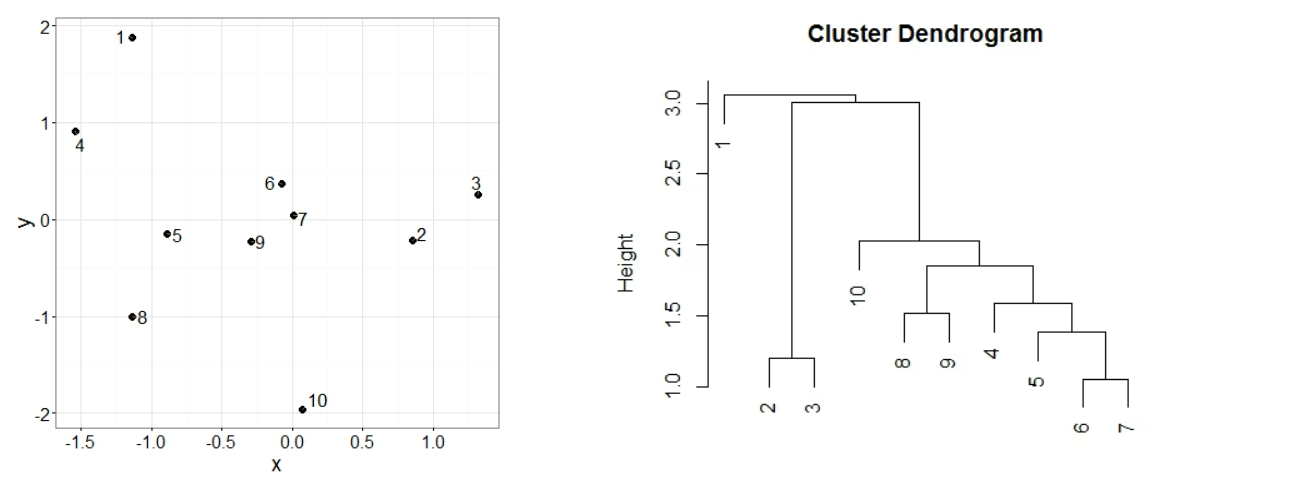

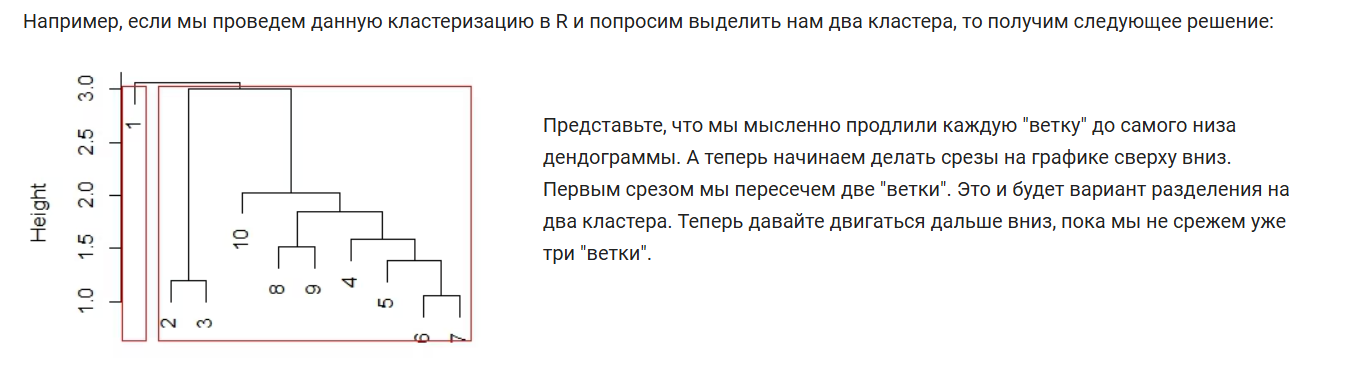

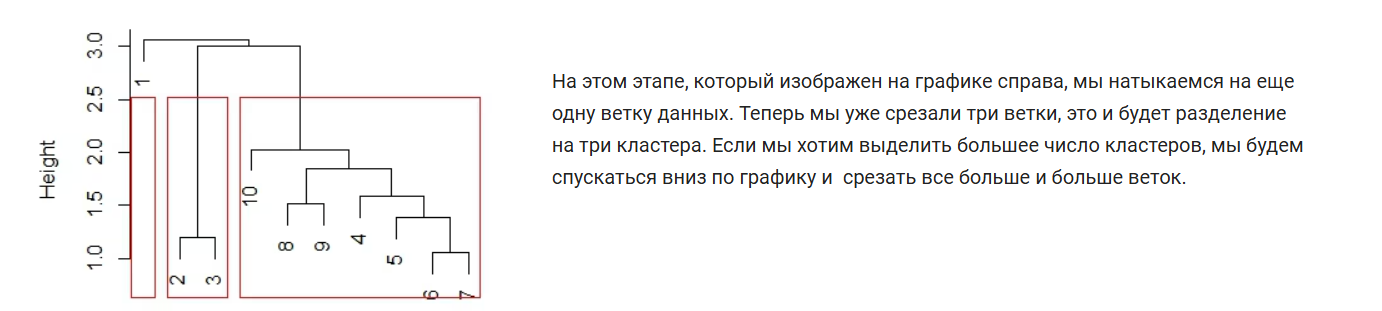

# 3.5 Введение в метод анализа главных компонент

### Основные определения и тезисы:   
**Метод анализа главных компонент (PCA, Principal Component Analysis)** -  это статистический метод, используемый для снижения размерности данных. Он позволяет выделить наиболее существенные переменные (главные компоненты), объясняющие наибольшую часть изменчивости в исходных данных. Изначальное(до сортировки) число главных компонент всегда равняется исходному числу переменных.  

**Алгортим анализа**:  
1) Подготовка данных: предварительная обработка, удаление выбросов, нормализация или стандартизация признаков;  
2) Вычисление ковариационной матрицы или корреляционной матрицы исходных признаков;  
3) Вычисление главных компонент: Главные компоненты вычисляются как линейные комбинации исходных переменных. Первая главная компонента объясняет наибольшую долю изменчивости(дисперсию) в данных, вторая компонента объясняет следующую по величине долю, и так далее;    
4) Сортировка собственных значений в порядке убывания и выбор наиболее информативных компонент.  
 
В случае сильной корреляции двух переменных, регрессионная прямая может стать **осью главной компоненты**(РС1). Тогда значения новой интегративной переменной - это проекция(расстояние) на ось РС1.  
![image.png](attachment:d42ff92a-2266-43db-9052-588be5b776ee.png)
Значения по оси РС1 - это значения корреляции м/у двумя переменными. Например, OX-рост OY-вес, тогда РС1-конституция тела. Если значение PC1 близко к максимуму, то это означает что значения по росту и весу тоже значительно. А уменьшение значения PC1 - означает одновременное уменьшение роста и веса.  

Чем сильнее корреляция между переменными, тем меньше информации потеряется. При этом "знак" отклонения не учитывается, т.е. зная только значение по оси РС1 мы не можем знать, в какую сторону от регрессионной прямой отклоняется предсказанное наблюдение.  

Информация об отклонении предсказанного значения хранится в оси РС2 (во второй компоненте) - перпендикуляру оси РС1.  
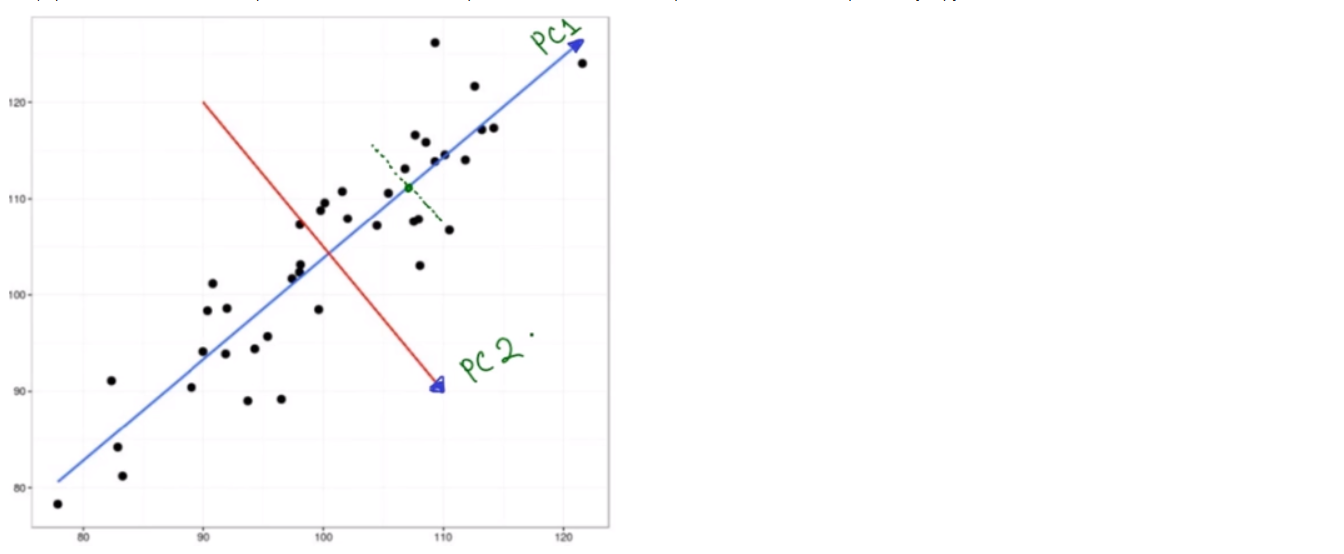

Информация по оси РС2 увеличивает процент объяснённой дисперсии всего на 4.5%, что позволяет не учитывать эту информацию.  
Таким образом, корреляционная прямая(РС1), становится одной новой переменной (интегративной переменной) вместо двух переменных по осям OX и OY. Что позволяет снизить размерность данных.  
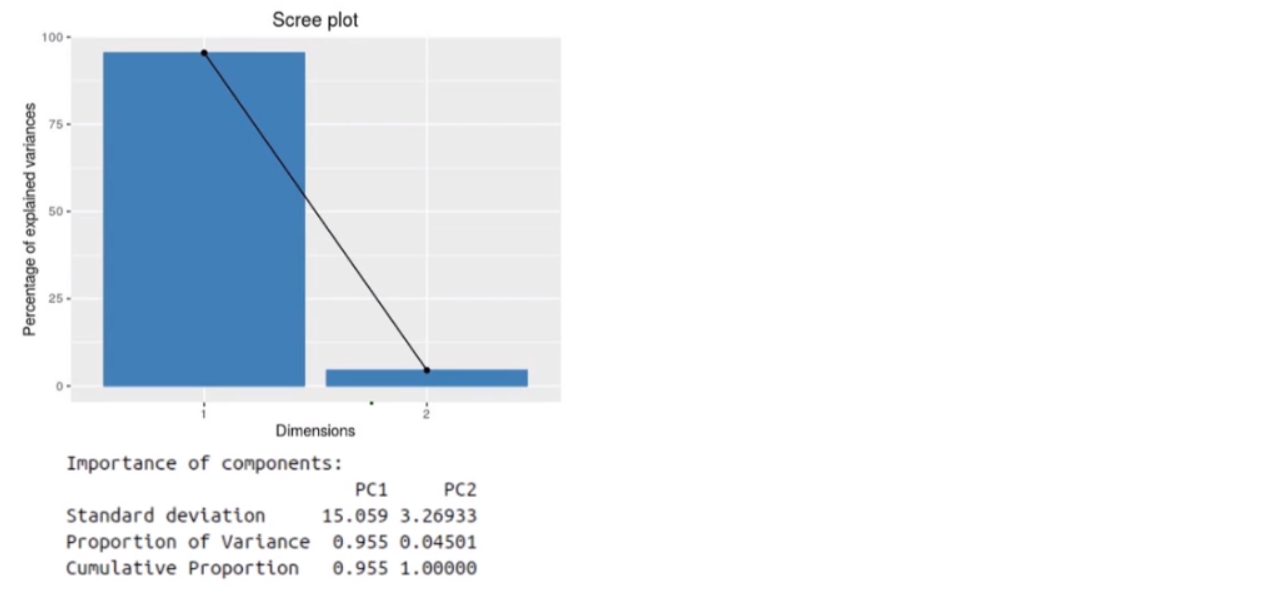


Если на графике biplot угол между переменными равен 90 градусов, значит коэффициент корреляции межу ними равняется нулю. Если угол - тупой, то корреляция отрицательная.  
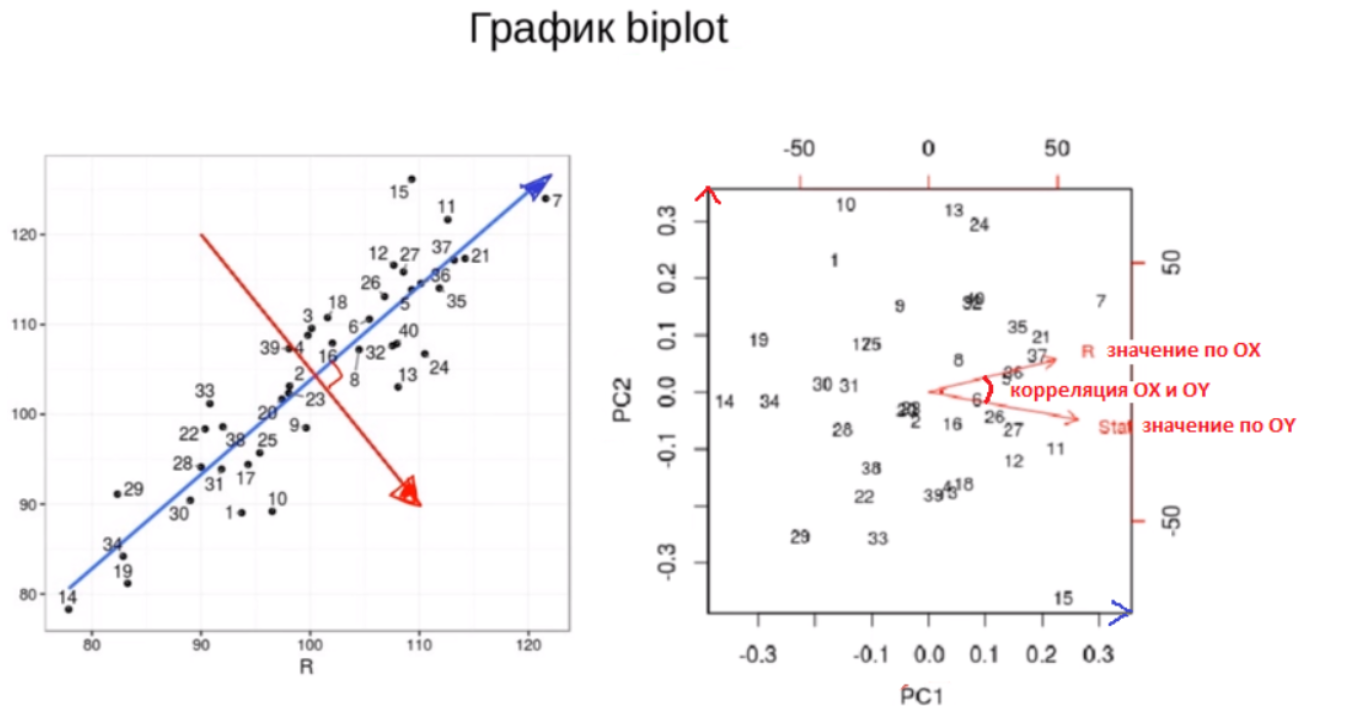

После формирования первой компоненты(PC1), можно избавиться от переменных R и stat. При этом потеряется около 4.5% информации (исходной изменчивости). 
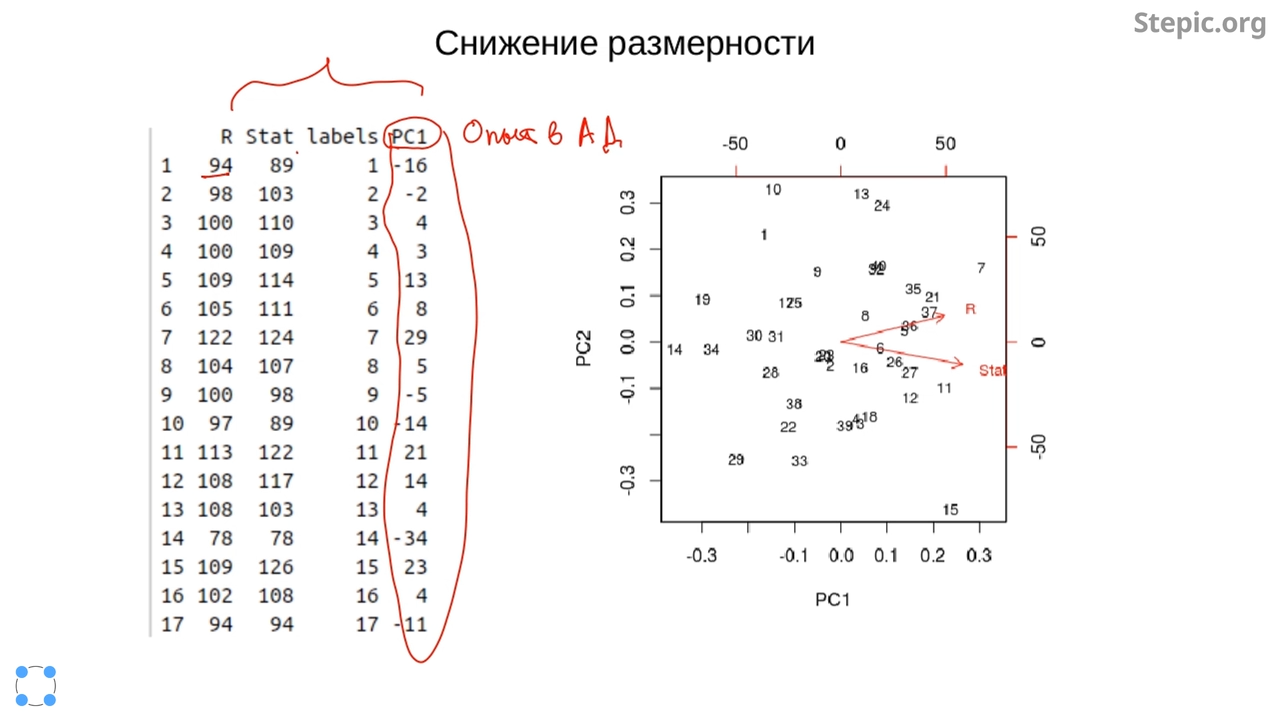

## Пример кода на python

In [112]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

#pip install pca
from pca import pca

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

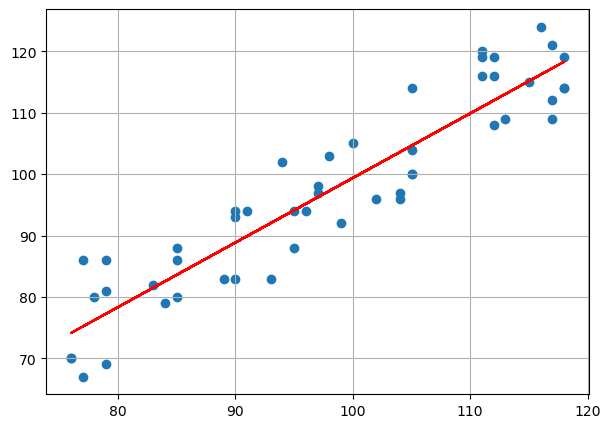

In [134]:
""" Реализация PCA с двумя переменными с помощью библиотеки pca """
# генерация линейной зависимости оценок
random_df = pd.DataFrame()
random_df["R"] = np.random.randint(75,120,50) # генерирует случайные целые числа в диапазоне от 75 до 120
random_df["stat"] = [elem + np.random.randint(-10,10) for elem in random_df["R"]] # делает разброс +-10

# диаграмма рассеивания 
plt.figure(figsize=(7, 5))
plt.scatter(random_df["R"], random_df["stat"])

# регрессионная прямая
b1, b0 = np.polyfit(random_df["R"], random_df["stat"], 1) #  b0 - intercept, b1 - slope
plt.plot(random_df["R"], b0 + b1*random_df["R"], color='red')
plt.grid()

plt.show()

[30-07-2025 14:09:09] [pca.pca] [INFO] Extracting column labels from dataframe.
[30-07-2025 14:09:09] [pca.pca] [INFO] Extracting row labels from dataframe.
[30-07-2025 14:09:09] [pca.pca] [INFO] The PCA reduction is performed on the 2 columns of the input dataframe.
[30-07-2025 14:09:09] [pca.pca] [INFO] Fit using PCA.
[30-07-2025 14:09:09] [pca.pca] [INFO] Compute loadings and PCs.
[30-07-2025 14:09:09] [pca.pca] [INFO] Compute explained variance.
[30-07-2025 14:09:09] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[30-07-2025 14:09:09] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[30-07-2025 14:09:09] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[30-07-2025 14:09:09] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[30-07-2025 14:09:09] [scatterd.scatterd] [INFO] Create scatterplot


<Figure size 500x500 with 0 Axes>

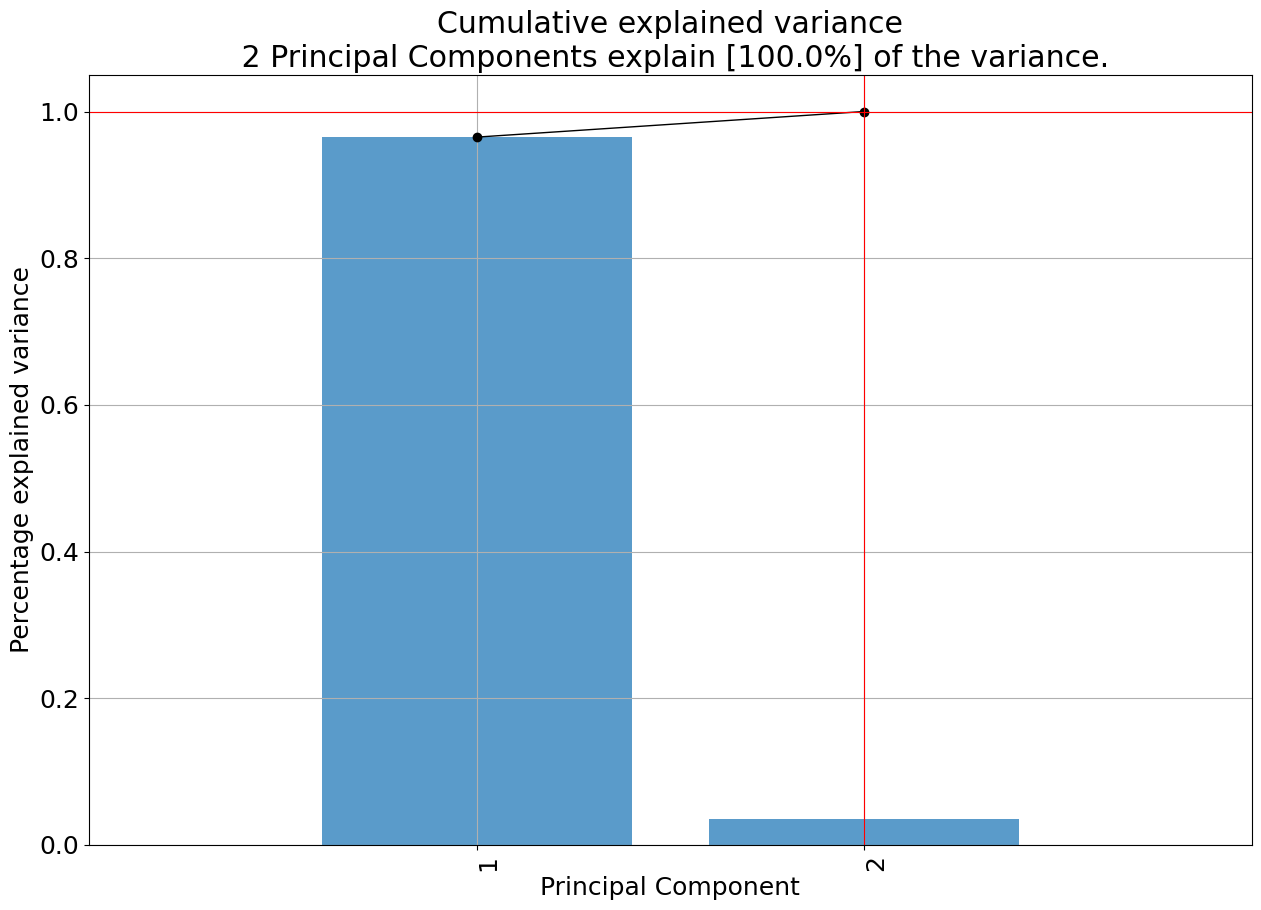

<Figure size 500x500 with 0 Axes>

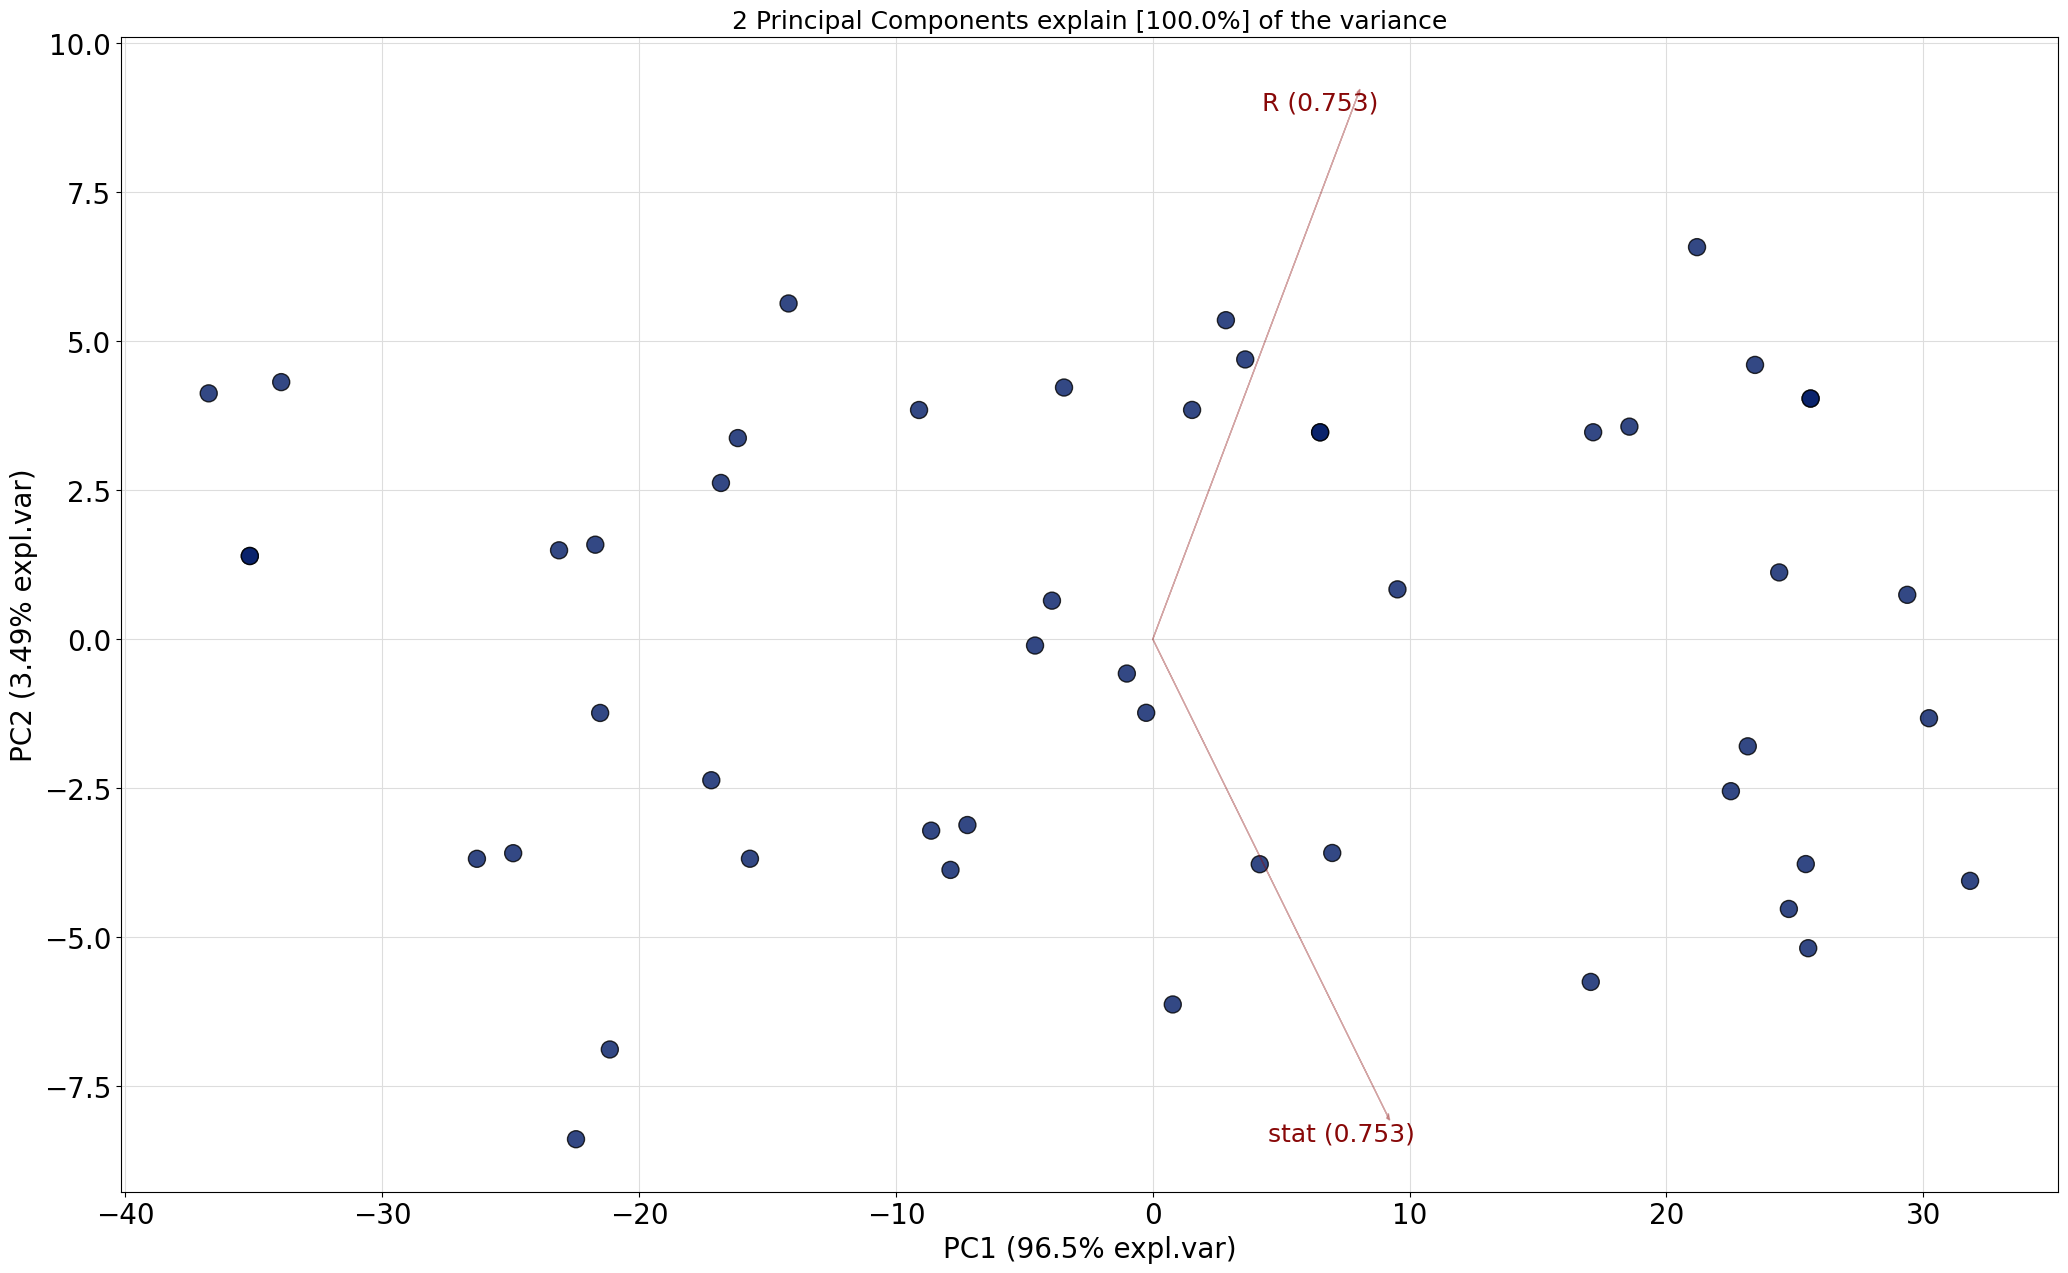

In [148]:
features = ['R', 'stat']
X = random_df[features]

# модель PCA с 2-мя компонентами
model = pca(n_components=2)
results = model.fit_transform(X)

# столбчатая диаграмма
plt.figure(figsize=(5, 5))
fig, ax = model.plot()

plt.figure(figsize=(5, 5))
fig, ax = model.biplot(n_feat=2)
plt.show()

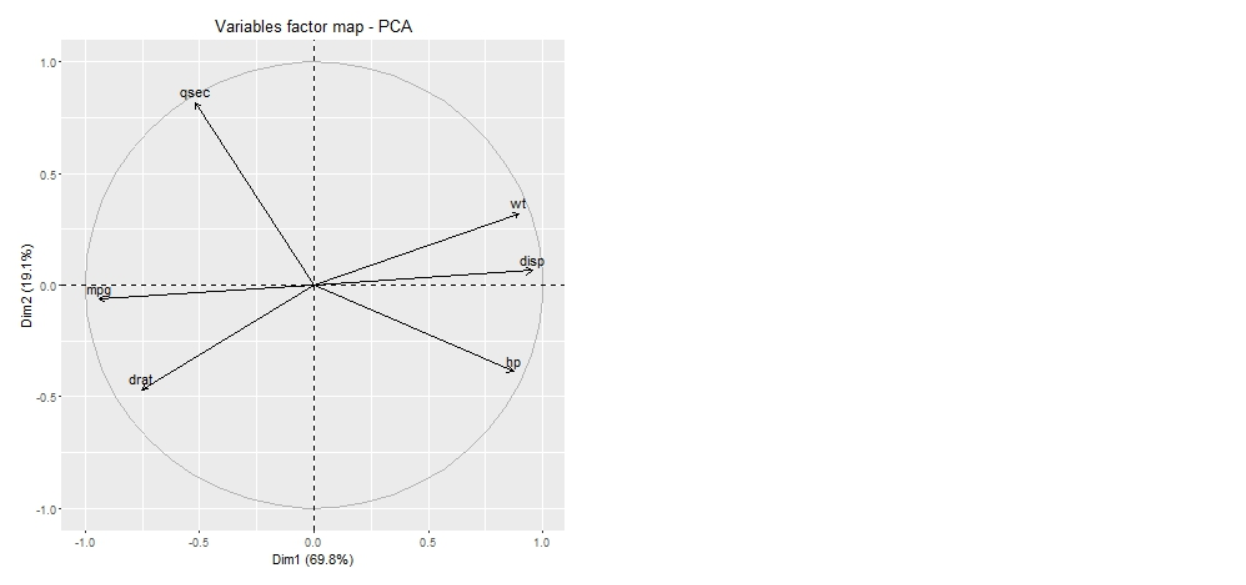

Объясню рассуждения в том порядке ответов, как они мне попадились

1. **Переменные wt и drat взаимосвязаны отрицательно**. Да, потому что они почти на одной линии и направлены в разные стороны. Значит, корреляция есть, но отрицательная. Если я правильно понял, то острый угол (0-90) - положительная корреляция, чем меньше, тем корреляция больше. Тупой угол (90-180) - отрицательная, чем ближе к 180, тем выше корреляция. А вот если ровно 90, то корреляции нет. Ну и чем ближе к 90 с той или другой стороны, тем корреляция слабее.

2. **Вторая главная компонента объясняет большую часть изменчивости, чем первая главная компонента**. Нет, потому что по графику видно, что первая объясняет 69,8%, а вторая - 19,1%. Так что первая больше объясняет

3. **Значения первой главной компоненты в большей степени определяют значения переменных mpg, disp, hp, drat и wt. Значения второй главной компоненты в большей степени определяют значения переменной qseс**.  Да, и вот почему: мы видим, что все переменные, кроме qsec, под углами меньше 45 градусов в оси первой компоненты, значит,  про них все верно. А у qsec угол с осью первой компоненты больше, чем с осью второй, значит, она ближе ко второй, т.е. и про нее верно

4. **Первая главная компонента объясняет большую часть изменчивости, чем вторая главная компонента**. Да. Это утверждение противоположно второму, и тут оно соответствует действительности: у первой компоненты 69,8 %, у второй - 19,1% - первая больше объясняет.